In [710]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [711]:
df = pd.read_csv("playground-series-s4e2/train.csv")
df_test = pd.read_csv("playground-series-s4e2/test.csv")

In [712]:
df = df.drop("id", axis=1)

In [713]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,Male,25.137087,1.766626,114.187096,yes,yes,2.919584,3.000000,Sometimes,no,2.151809,no,1.330519,0.196680,Sometimes,Public_Transportation,Obesity_Type_II
20754,Male,18.000000,1.710000,50.000000,no,yes,3.000000,4.000000,Frequently,no,1.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight
20755,Male,20.101026,1.819557,105.580491,yes,yes,2.407817,3.000000,Sometimes,no,2.000000,no,1.158040,1.198439,no,Public_Transportation,Obesity_Type_II
20756,Male,33.852953,1.700000,83.520113,yes,yes,2.671238,1.971472,Sometimes,no,2.144838,no,0.000000,0.973834,no,Automobile,Overweight_Level_II


In [714]:
df.shape

(20758, 17)

In [715]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          20758 non-null  str    
 1   Age                             20758 non-null  float64
 2   Height                          20758 non-null  float64
 3   Weight                          20758 non-null  float64
 4   family_history_with_overweight  20758 non-null  str    
 5   FAVC                            20758 non-null  str    
 6   FCVC                            20758 non-null  float64
 7   NCP                             20758 non-null  float64
 8   CAEC                            20758 non-null  str    
 9   SMOKE                           20758 non-null  str    
 10  CH2O                            20758 non-null  float64
 11  SCC                             20758 non-null  str    
 12  FAF                             20758 non-n

In [716]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,23.841804,1.700245,87.887768,2.445908,2.761332,2.029418,0.981747,0.616756
std,5.688072,0.087312,26.379443,0.533218,0.705375,0.608467,0.838302,0.602113
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.631856,66.000000,2.000000,3.000000,1.792022,0.008013,0.000000
50%,22.815416,1.700000,84.064875,2.393837,3.000000,2.000000,1.000000,0.573887
75%,26.000000,1.762887,111.600553,3.000000,3.000000,2.549617,1.587406,1.000000
max,61.000000,1.975663,165.057269,3.000000,4.000000,3.000000,3.000000,2.000000


In [717]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [718]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64

In [719]:
order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

/tmp/ipykernel_193835/1791164112.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


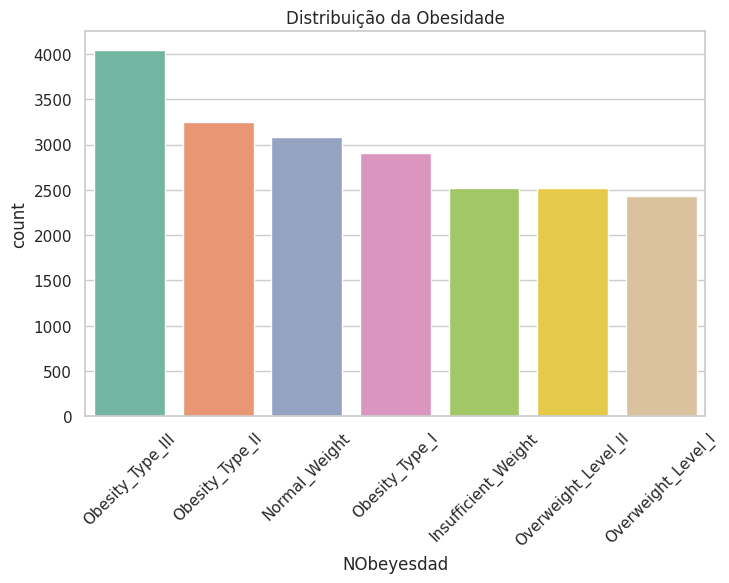

In [720]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='NObeyesdad',
    order=df['NObeyesdad'].value_counts().index,
    palette="Set2"
)

plt.xticks(rotation=45)
plt.title("Distribuição da Obesidade")
plt.show()

A classe mais frequente é Obesity_Type_III, enquanto Overweight_Level_I/II e Insufficient_Weight são as menos representadas.
O dataset é relativamente equilibrado, mas pode gerar leve viés para as classes mais comuns.

Variáveis numéricas


In [721]:
num_cols = df.select_dtypes(include='number').columns
num_cols = [col for col in num_cols if col != 'NObeyesdad']

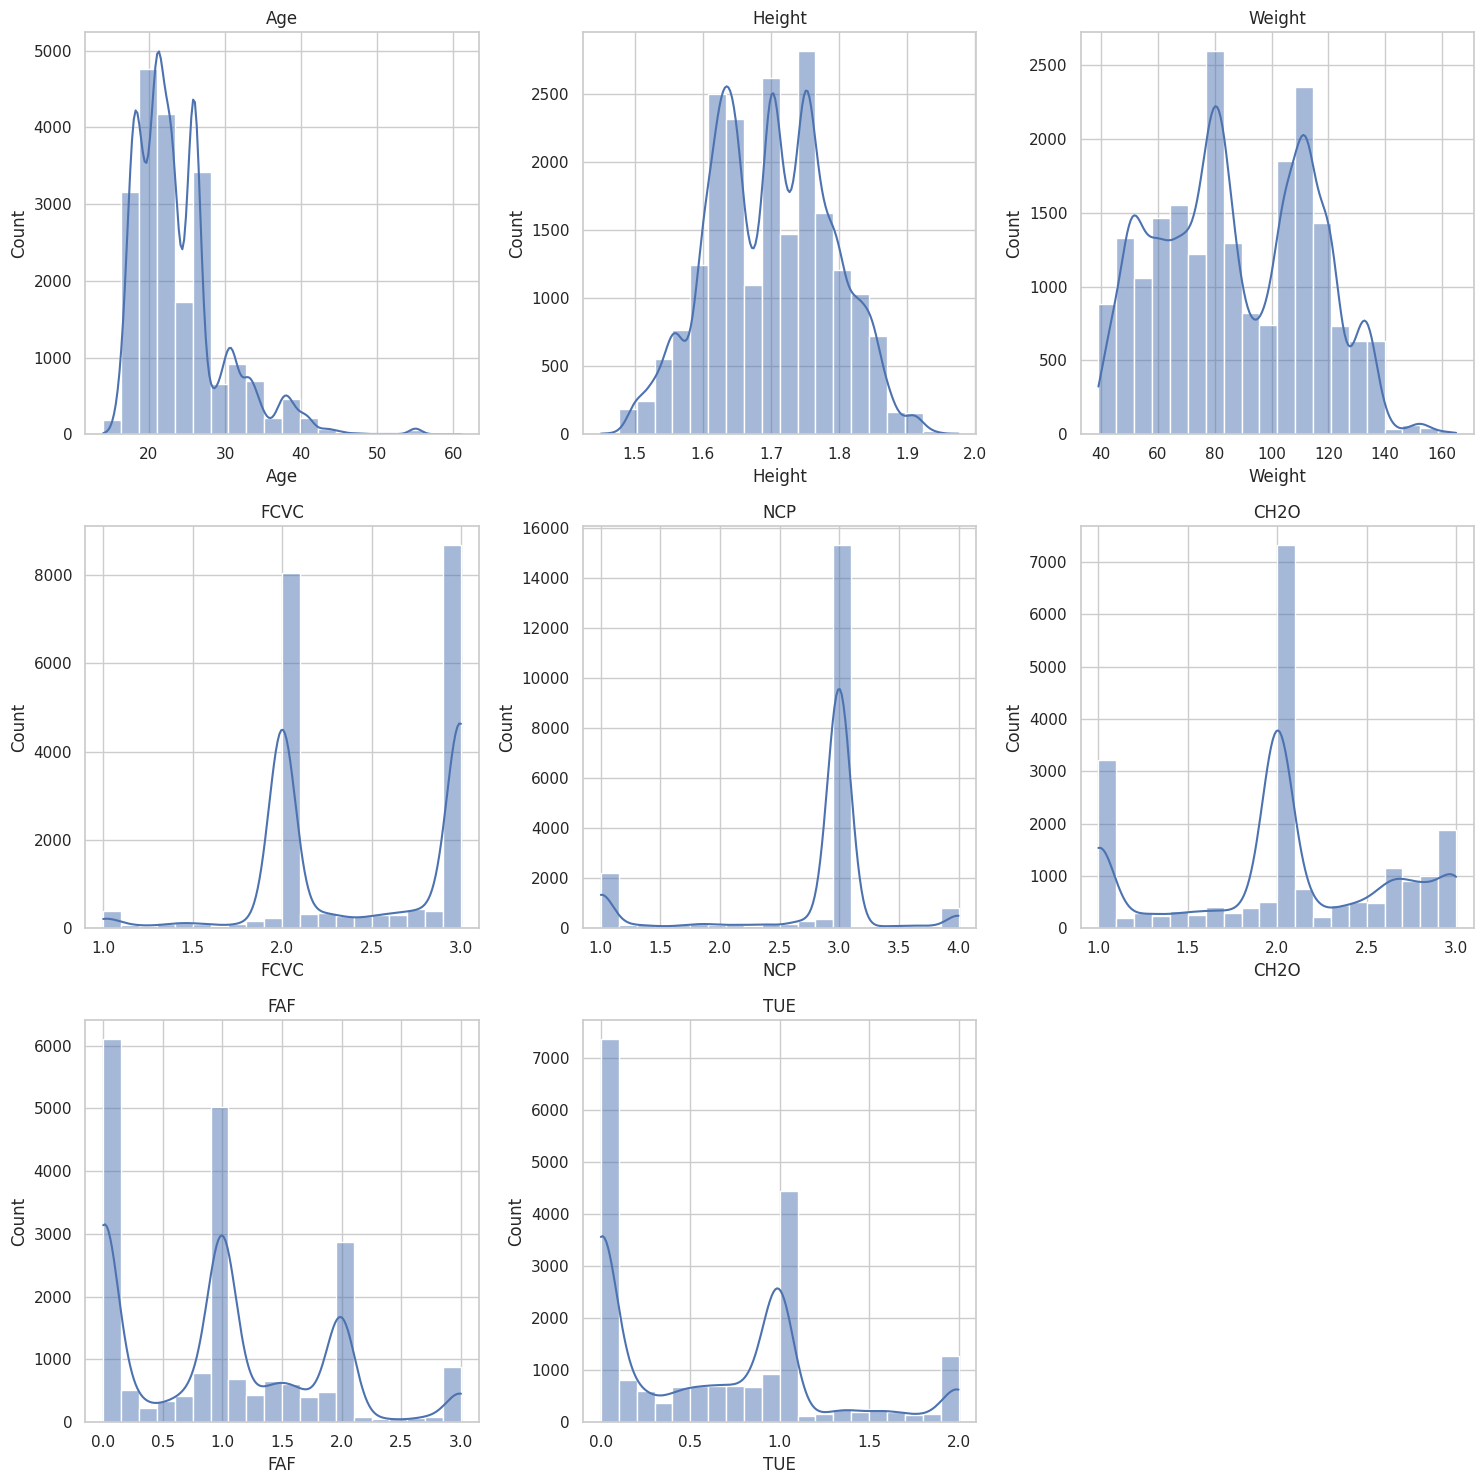

In [722]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col].dropna(),
        bins=20,
        kde=True,        
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- **Age**: Concentração predominante em jovens adultos (entre 18 e 25 anos), com uma cauda longa à direita indicando poucos indivíduos acima de 40 anos.
- **Height**: Distribuição aproximadamente normal, com a maior parte da amostra medindo entre 1,60m e 1,80m.
- **Weight**: Distribuição bimodal, com picos claros em torno de 80kg e 110kg, refletindo a diversidade de perfis de massa corporal no dataset.
- **FCVC**: Picos bem definidos nos valores 2 e 3, indicando que a maioria consome vegetais com frequência moderada a alta.
- **NCP**: Forte concentração no valor 3, evidenciando que o padrão de três refeições principais por dia é o mais comum.
- **CH2O**: Picos em 1, 2 e 3 litros, com a maior concentração em torno de 2 litros diários de consumo de água.
- **FAF**: Alta concentração no valor 0 (sedentarismo total), com picos menores em 1 e 2, indicando baixa frequência de atividade física na maioria.
- **TUE**: Grande concentração no valor 0 e um pico em 1, mostrando que a maior parte da amostra gasta entre zero e uma hora em dispositivos tecnológicos.

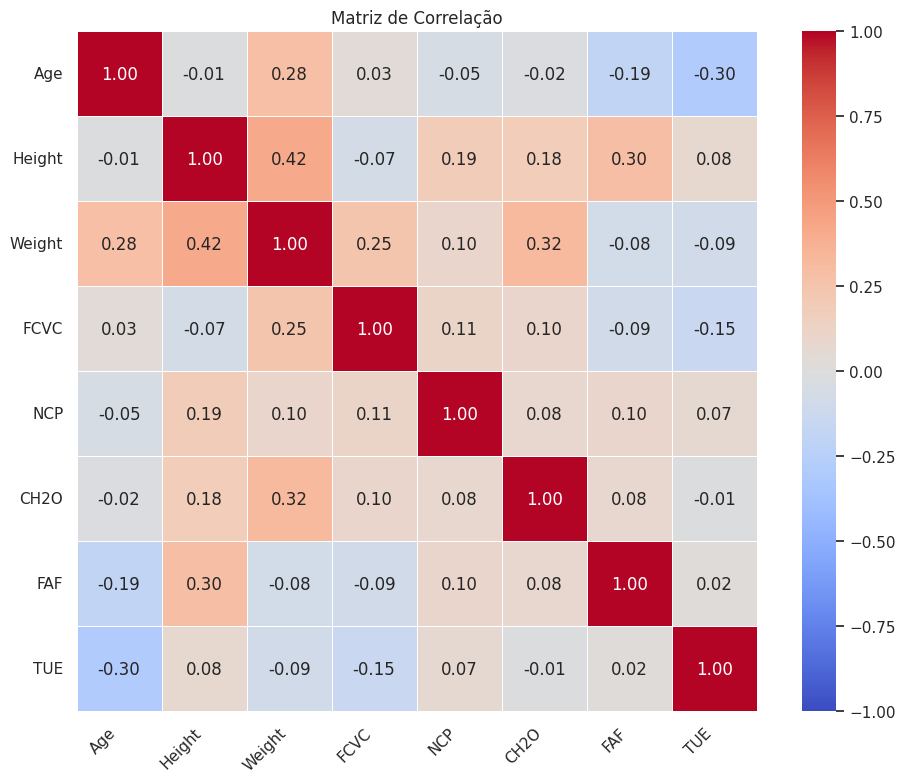

In [723]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title("Matriz de Correlação")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


*   **Weight & Height (0.42)**: Esta é a correlação positiva mais forte da matriz, o que faz sentido físico, já que pessoas mais altas tendem a pesar mais.
*   **Weight & CH2O (0.32)**: Indica uma relação moderada onde indivíduos com maior peso tendem a relatar um consumo maior de água.
*   **Age & TUE (-0.30)**: Correlação negativa que sugere que, conforme a idade aumenta, o tempo gasto em dispositivos tecnológicos tende a diminuir.
*   **Height & FAF (0.30)**: Mostra uma leve tendência de que pessoas mais altas no dataset praticam mais atividades físicas.
*   **Age & Weight (0.28)**: Existe uma correlação positiva baixa, indicando que o peso tende a aumentar levemente com a idade.
*   **Independência das Variáveis**: A maioria das outras relações (como **NCP** com quase tudo) possui valores próximos de zero, sinalizando que esses hábitos não estão fortemente interligados entre si.

Boxplots

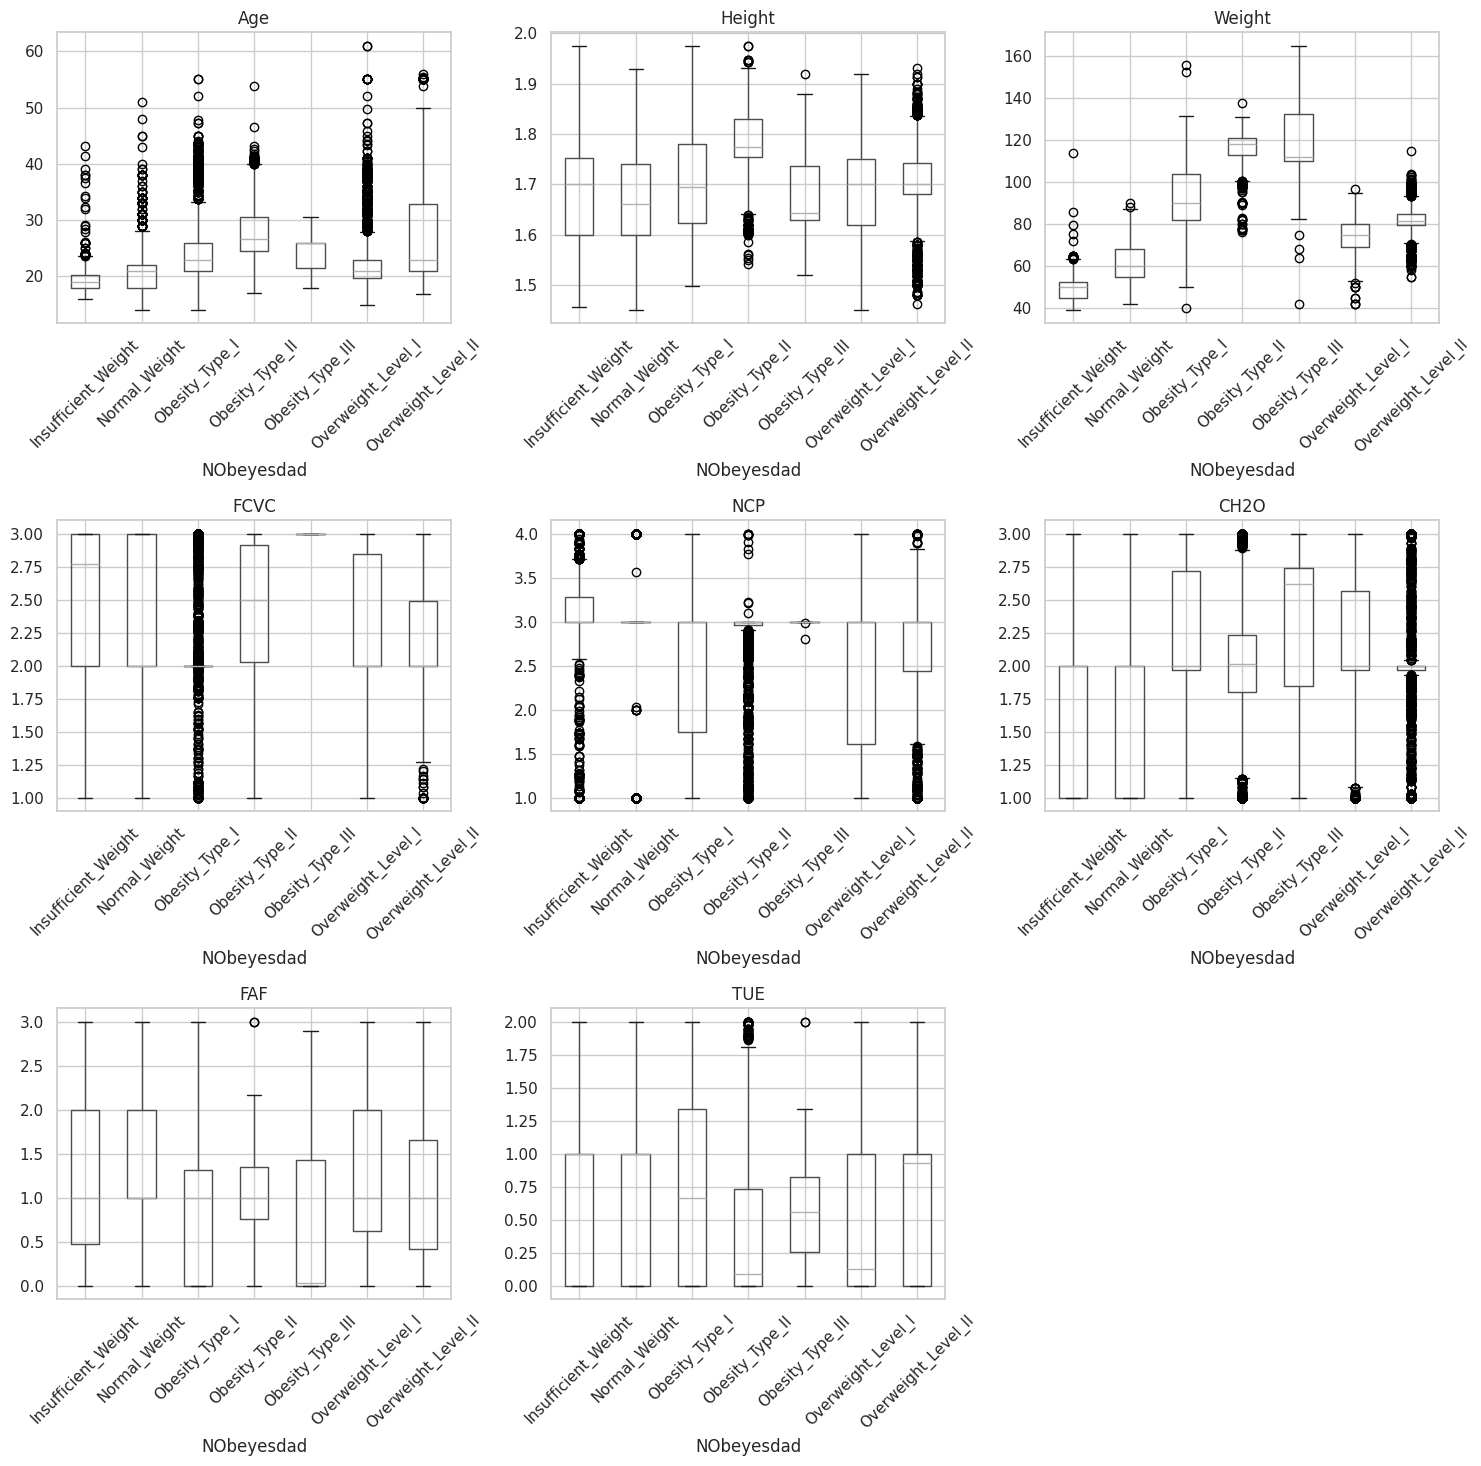

In [724]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='NObeyesdad', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()
plt.show()

*   **Age**: A maioria das classes de obesidade se concentra em uma faixa etária jovem, mas as categorias **Obesity_Type_I** e **II** apresentam muitos *outliers* de idade avançada.
*   **Height**: A altura é visivelmente maior na classe **Obesity_Type_I**, o que explica por que indivíduos desse grupo podem ter pesos elevados sem necessariamente estarem nos níveis mais altos de obesidade.
*   **Weight**: Confirma a tendência anterior de crescimento degrausado, com a **Obesity_Type_III** mantendo o patamar de peso mais alto e estável.
*   **FCVC**: O consumo de vegetais é alto e quase constante na classe **Obesity_Type_III**, enquanto as outras categorias apresentam uma variação muito maior.
*   **NCP**: O número de refeições principais é bastante padronizado em 3 para quase todas as classes, com maior dispersão apenas em **Obesity_Type_I**.
*   **CH2O**: Nota-se que os grupos em níveis mais altos de obesidade (**Type II e III**) tendem a ter uma mediana de consumo de água ligeiramente superior.
*   **FAF**: O sedentarismo é gritante na **Obesity_Type_II** (mediana em zero), enquanto a **Obesity_Type_I** e os grupos de **Overweight** mostram uma prática de atividade física mais distribuída.
*   **TUE**: O tempo de uso de tecnologia é baixíssimo na **Obesity_Type_III**, contrastando com as classes iniciais, onde o uso é mais frequente e variado.

Detecção de Outliers

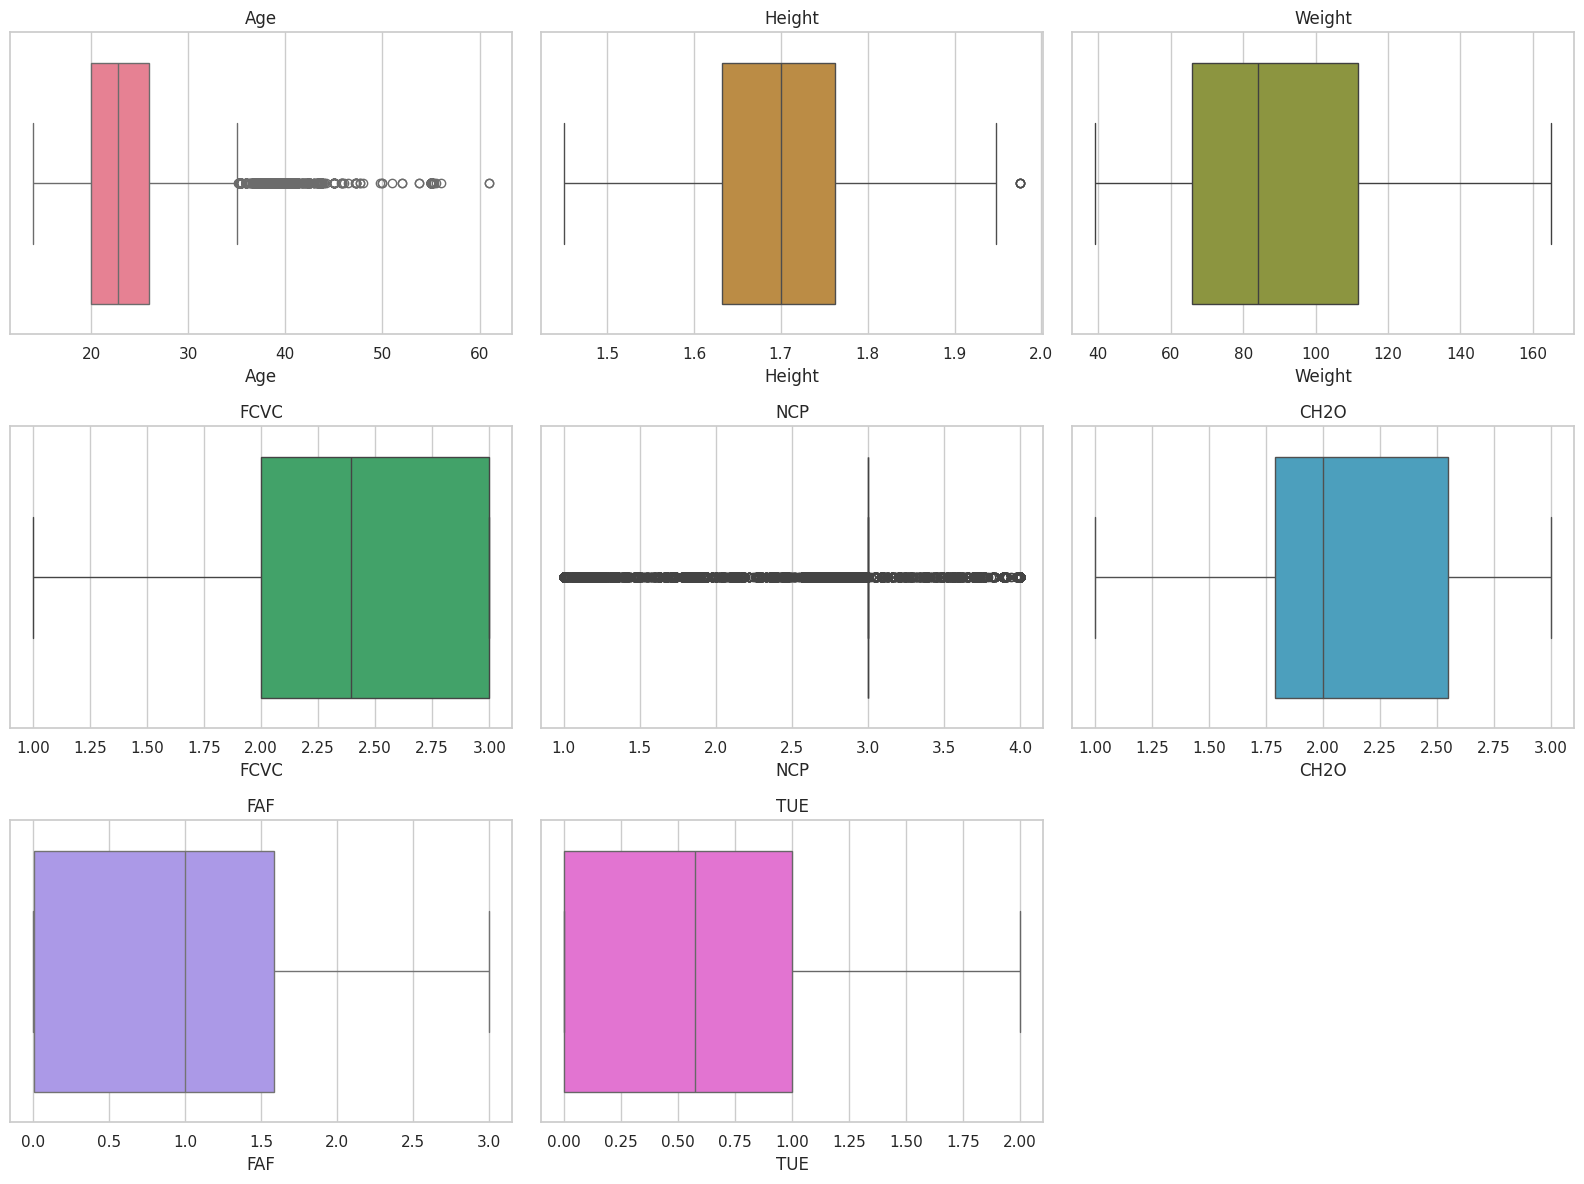

In [725]:
palette = sns.color_palette("husl", len(num_cols))  # cores diferentes

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color=palette[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

*   **Age**: A mediana está em torno dos 23 anos, com uma grande quantidade de *outliers* acima dos 35 anos, indicando uma amostra predominantemente jovem.
*   **Height**: Distribuição bem simétrica, com a maioria entre 1,63m e 1,76m, e poucos valores extremos.
*   **Weight**: Apresenta uma dispersão considerável, com a mediana próxima aos 84kg e uma amplitude que vai de 40kg a mais de 160kg.
*   **FCVC**: A maior parte da amostra consome vegetais com frequência, com o terceiro quartil batendo no valor máximo (3).
*   **NCP**: Variável extremamente concentrada no valor 3, com uma quantidade massiva de *outliers* abaixo disso, mostrando que quase todo mundo faz 3 refeições por dia.
*   **CH2O**: Consumo de água bem distribuído entre 1 e 3 litros, com a mediana cravada em 2 litros.
*   **FAF**: Distribuição que reforça o sedentarismo; a mediana está em 1, mas o primeiro quartil está em 0, indicando que boa parte da amostra pratica pouca ou nenhuma atividade física.
*   **TUE**: A maioria gasta pouco tempo em dispositivos tecnológicos, com a mediana abaixo de 1 hora e o topo da caixa chegando em 1.

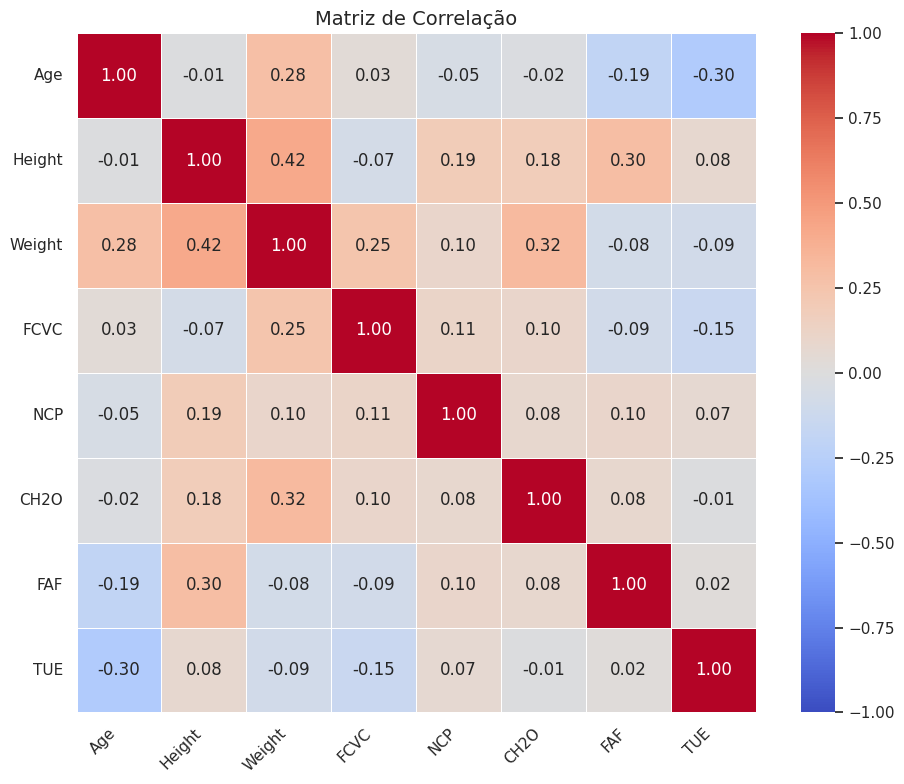

In [726]:
df_num = df.select_dtypes(include=np.number)
corr = df_num.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,           
    fmt=".2f",            
    cmap="coolwarm",      
    vmin=-1, vmax=1,      
    square=True,          
    linewidths=0.5        
)

plt.title("Matriz de Correlação", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

- **Weight & Height**: correlação positiva moderada (0.42), indicando que indivíduos mais altos tendem a ter maior peso corporal.
- **Weight & CH2O**: correlação positiva (0.32), sugerindo que pessoas com maior peso tendem a consumir mais água.
- **Age & TUE**: correlação negativa moderada (-0.30), evidenciando que o uso de dispositivos tecnológicos diminui com o aumento da idade.
- **Height & FAF**: correlação positiva (0.30), associando uma estatura maior a uma frequência levemente superior de atividade física.
- **Weight & Age/FCVC**: correlações positivas fracas (0.28 e 0.25), mostrando que idade e consumo de vegetais têm influência limitada no peso isoladamente.
- **Baixa Interdependência**: a maioria das variáveis apresenta correlação próxima a zero, indicando que os fatores de estilo de vida agem de forma independente no dataset.

In [727]:
df['IMC'] = df['Weight'] / (df['Height'] ** 2)
df['ACTIVE_TRANSPORT'] = df['MTRANS'].isin(['Walking', 'Bike']).astype(int)
df = df.drop(columns=['Weight', 'Height', 'MTRANS'])

O IMC sintetiza informações de peso e altura, sendo um indicador mais direto do nível de obesidade.Já o tipo de transporte foi transformado em um indicador binário de atividade física, destacando comportamentos mais ativos.

/tmp/ipykernel_193835/776932255.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


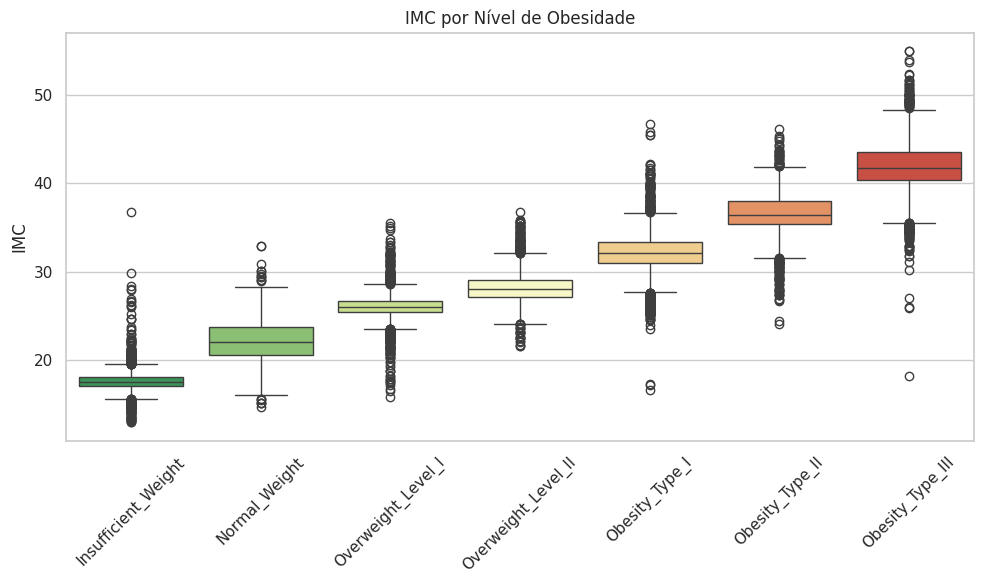

In [728]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='NObeyesdad',
    y='IMC',
    order=order,
    palette="RdYlGn_r" 
)

plt.xticks(rotation=45)
plt.title("IMC por Nível de Obesidade")
plt.xlabel("")
plt.ylabel("IMC")

plt.tight_layout()
plt.show()

O IMC se mostrou um preditor excelente, com as medianas subindo em degraus bem definidos para cada classe. A categoria Obesity_Type_III é a mais evidente, ficando isolada no topo da escala. Já as classes de Overweight I e II apresentam muita sobreposição, o que indica que o IMC sozinho não as diferencia totalmente e o modelo precisará das outras variáveis de hábito. Além disso, a presença de diversos outliers mostra que a classificação final sofre variações que vão além do cálculo básico de massa e altura.

Variáveis Categóricas

In [729]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols = [col for col in cat_cols if col != 'NObeyesdad']
cat_cols

/tmp/ipykernel_193835/3391862876.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


['Gender',
 'family_history_with_overweight',
 'FAVC',
 'CAEC',
 'SMOKE',
 'SCC',
 'CALC']

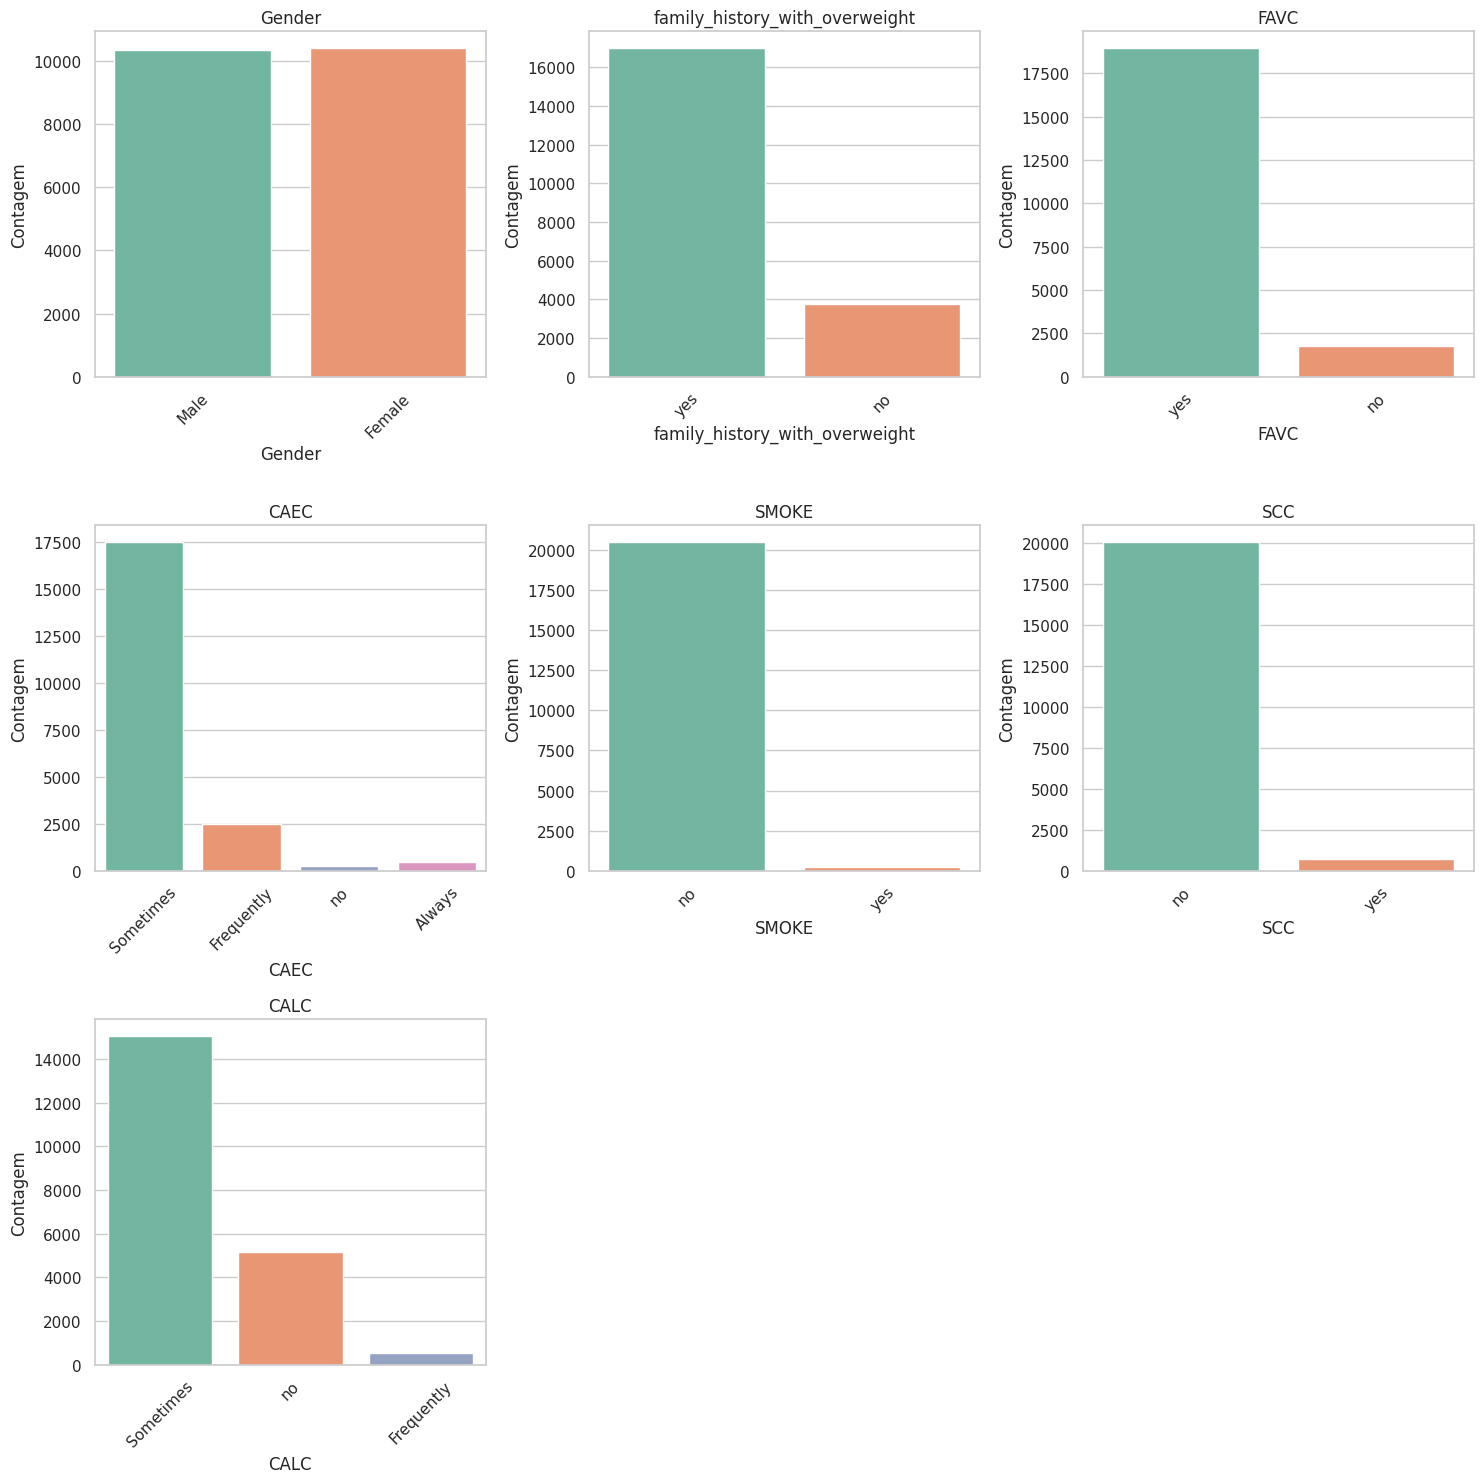

In [730]:

n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))


fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    sns.countplot(data=df, x=col, ax=ax, hue=col, palette="Set2", legend=False)
    
    ax.set_title(f"{col}")
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel("Contagem")

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

*   **Gender**: A amostra está perfeitamente equilibrada, com praticamente 50% de indivíduos de cada sexo.
*   **family_history_with_overweight**: Existe uma forte predominância (mais de 80%) de pessoas com histórico familiar de sobrepeso.
*   **FAVC (Consumo de alimentos calóricos)**: A grande maioria (cerca de 90%) admite consumir alimentos com alto teor calórico frequentemente.
*   **CAEC (Consumo de alimentos entre refeições)**: O comportamento às vezes é o mais comum, abrangendo mais de 80% da amostra.
*   **SMOKE**: A incidência de fumantes é baixíssima, com quase 100% da amostra declarando que não fuma.
*   **SCC (Monitoramento de calorias)**: Quase a totalidade dos indivíduos (perto de 95%) não realiza o monitoramento das calorias consumidas.
*   **CALC (Consumo de álcool)**: A maioria consome álcool, seguida por uma parcela significativa que não consome, e uma minoria que consome frequentemente.

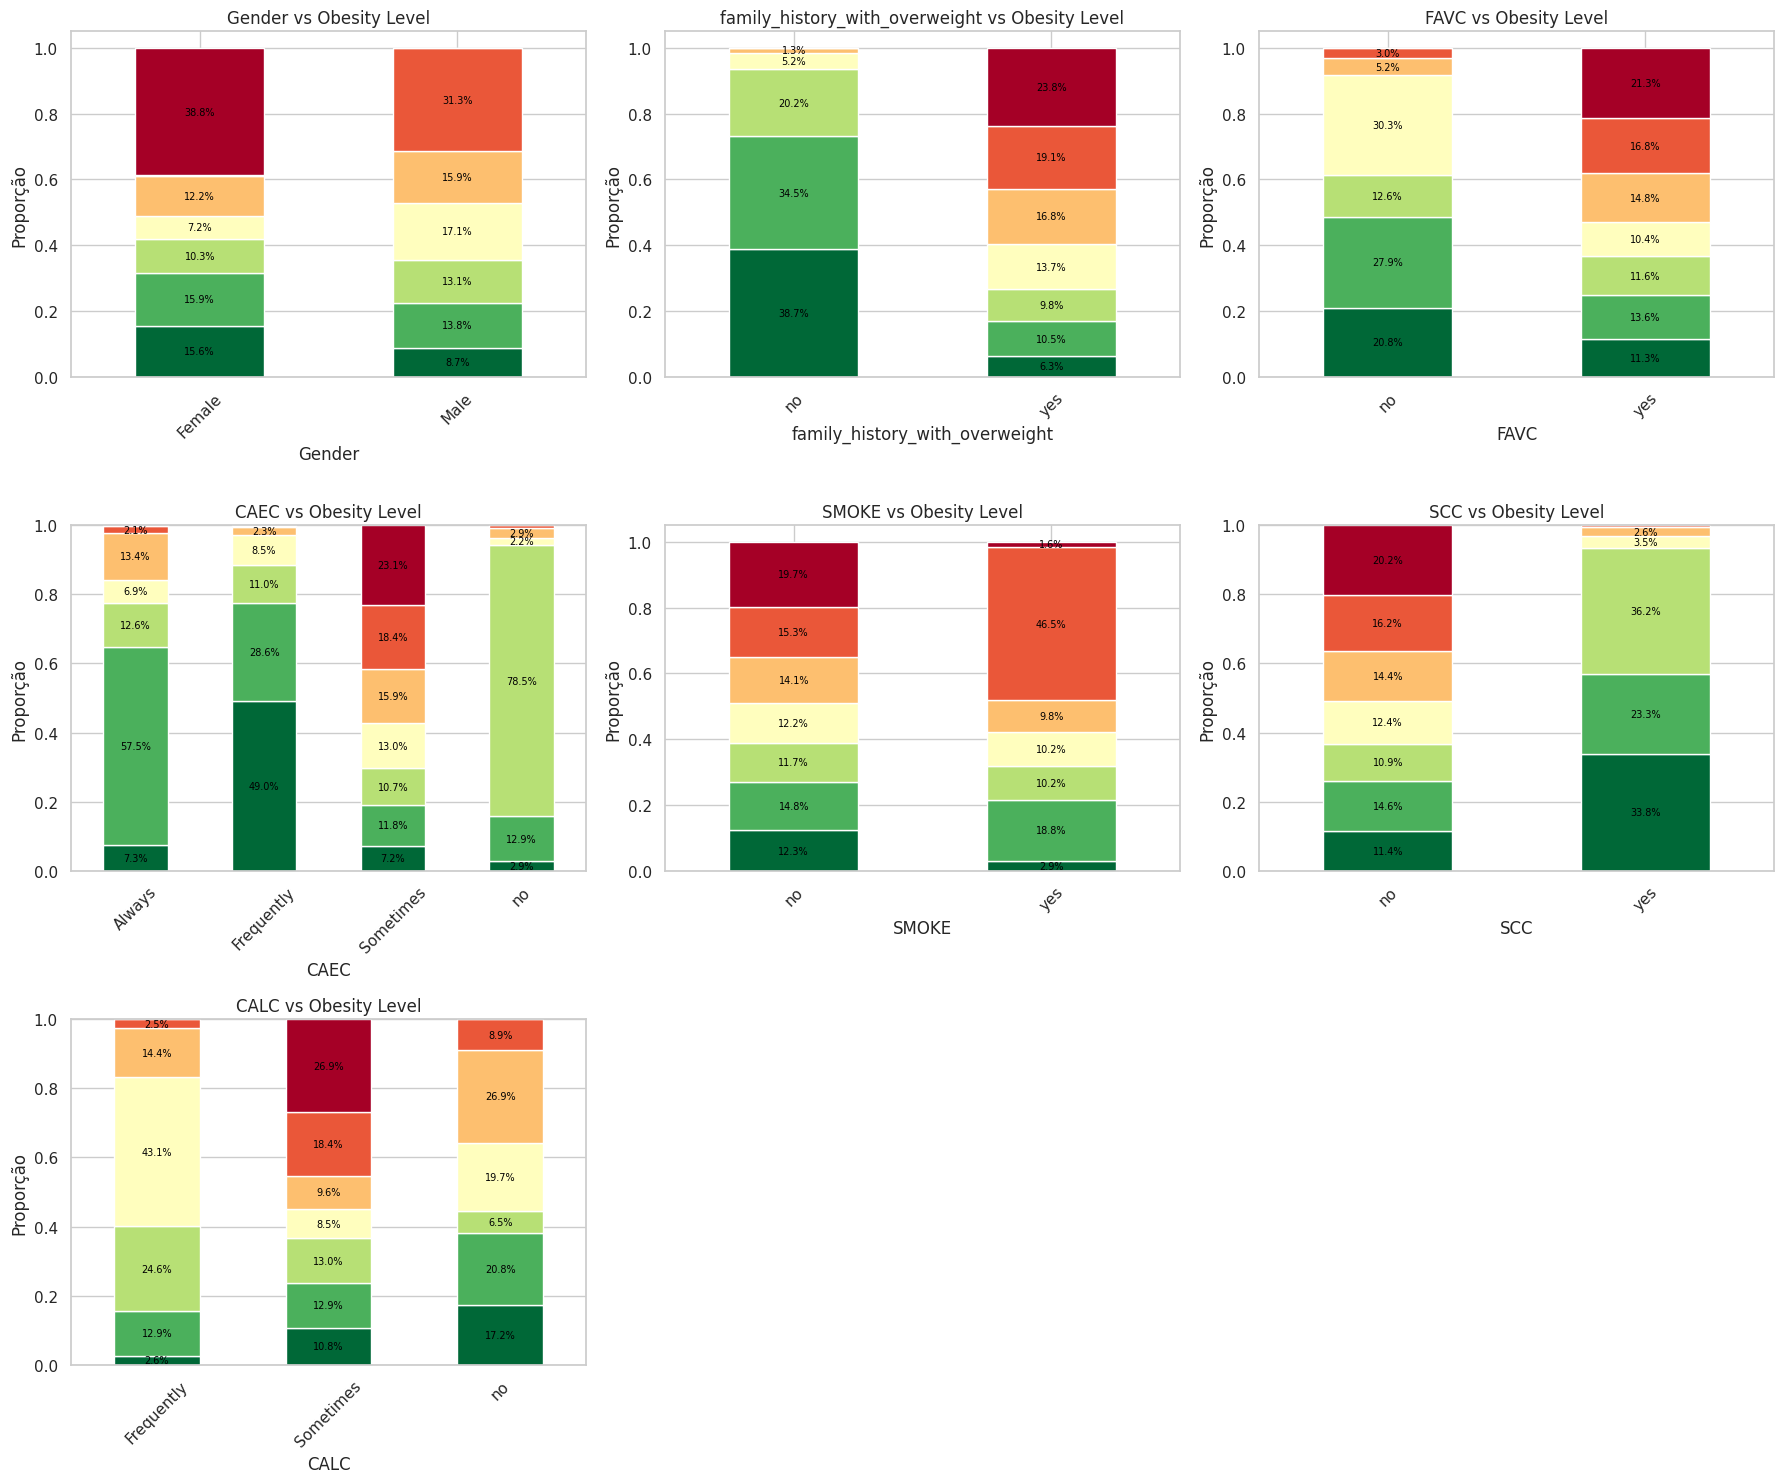

In [731]:
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()


for i, col in enumerate(cat_cols):
    ax = axes[i]

    ctab = pd.crosstab(
        df[col],
        df['NObeyesdad'],
        normalize='index'
    )[order]

    ctab.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        colormap='RdYlGn_r',
        legend=False
    )

    ax.set_title(f"{col} vs Obesity Level")
    ax.set_ylabel("Proporção")
    ax.tick_params(axis='x', rotation=45)

    for j, (idx, row) in enumerate(ctab.iterrows()):
        cumulative = 0
        for k, val in enumerate(row):
            if val > 0.01: 
                ax.text(
                    j,
                    cumulative + val / 2,
                    f"{val*100:.1f}%",
                    ha='center',
                    va='center',
                    fontsize=7,
                    color='black'
                )
            cumulative += val

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

*   **Gender**: Nota-se uma divisão clara por gênero em níveis críticos, a classe **Obesity_Type_III** é composta quase inteiramente por mulheres (38.8%), enquanto a **Obesity_Type_II** é predominantemente masculina (31.3%).
*   **family_history_with_overweight**: É um dos indicadores mais fortes; indivíduos sem histórico familiar são majoritariamente de peso normal ou insuficiente, enquanto quase todos os casos de obesidade severa (**Type I, II e III**) possuem histórico familiar ("yes").
*   **FAVC**: O consumo frequente de alimentos calóricos está presente em quase todas as categorias de obesidade, mas é interessante notar que quem não consome ("no") tem uma proporção muito maior de **Overweight_Level_II**.
*   **CAEC**: Pessoas que não comem entre as refeições ("no") estão massivamente concentradas na categoria **Overweight_Level_I** (78.5%), enquanto o hábito de comer "às vezes" ou "frequentemente" distribui os indivíduos por todas as classes de obesidade.
*   **SMOKE**: Embora existam poucos fumantes na amostra, o gráfico sugere que, entre eles ("yes"), há uma concentração muito alta de **Obesity_Type_II** (46.5%).
*   **SCC**: Indivíduos que monitoram calorias ("yes") têm uma chance significativamente maior de estar em categorias de **Insufficient Weight** ou **Normal Weight**, com quase nenhum caso de obesidade severa nesse grupo.
*   **CALC**: O consumo frequente de álcool está associado a uma grande proporção de **Overweight_Level_II** (43.1%), enquanto aqueles que não bebem ("no") apresentam uma distribuição mais equilibrada, incluindo mais casos de **Obesity_Type_I**.

Variáveis mais discriminativas

*   **IMC** : É a variável mais discriminativa, apresentando uma progressão clara em degraus e quase nenhum erro de sobreposição entre classes extremas.
*   **Weight (Peso)**: Mostra uma correlação direta com o aumento do nível de obesidade e foi o componente principal para o cálculo do IMC.
*   **Gender (Gênero)**: Extremamente discriminativa para as classes mais altas; mulheres compõem quase a totalidade da classe **Obesity_Type_III**, enquanto homens dominam a classe **Obesity_Type_II**.
*   **Family History (Histórico Familiar)**: Atua como um filtro essencial, pois quase todos os indivíduos em níveis de obesidade severa possuem histórico familiar positivo.
*   **FAF (Atividade Física)**: Relevante para diferenciar o perfil de sedentarismo, sendo uma característica marcante na classe **Obesity_Type_II**.
*   **SCC (Monitoramento de Calorias)**: Variável binária forte para identificar indivíduos em categorias de peso saudável ou insuficiente, que são os únicos que mantêm esse hábito de forma expressiva.
*   **TUE (Uso de Tecnologia)**: Diferencia especificamente a classe **Obesity_Type_III**, que apresenta um tempo de uso de dispositivos significativamente menor que as outras categorias.

### Decisões de pré-processamento


#### **1. Encoding**
*   **Variáveis Binárias**: Vamos converter atributos como `Gender`, `family_history_with_overweight`, `FAVC`, `SMOKE` e `SCC` para 0 e 1, já que elas só possuem duas categorias e o modelo precisa delas em formato numérico.
*   **Variáveis Ordinais**: No caso de `CAEC` e `CALC`, decidimos usar *Ordinal Encoding* para manter a hierarquia (de "no" até "Always"), garantindo que o modelo entenda que existe uma progressão na frequência desses hábitos.
*   **ACTIVE_TRANSPORT**: Criamos essa variável binária para simplificar os tipos de transporte, focando no que realmente importa para o problema: se o deslocamento envolve esforço físico ou não.

#### **2. Normalização e Escalonamento**
*   **Diferença de Escalas**: Variáveis têm intervalos muito diferentes, como o peso que vai de 40 a 160+ e a altura que fica entre 1.4 e 1.9.
*   **Justificativa**: Precisamos aplicar um escalonamento (como *StandardScaler*) para que variáveis com números maiores não "dominem" o modelo e acabem enviesando o aprendizado.

#### **3. Tratamento de Outliers**
*   **Identificação**: `Age` e `NCP` têm muitos valores atípicos nos boxplots.
*   **Decisão**: Em vez de simplesmente apagar esses dados,serão usados modelos de árvore, porque esses valores em `Age` representam pessoas reais mais velhas e em `NCP` mostram comportamentos alimentares que podem ser importantes para a classificação.

#### **4. Feature Engineering (IMC)**
*   **Justificativa**:  criar a coluna de **IMC** e remover peso e altura porque essa métrica sozinha já separa muito bem as 7 classes de obesidade, o que simplifica o modelo e reduz dados repetidos.

### Etapa 2 - Classificadores


### **Modelagem de Probabilidade**
*   **Escolha do Gaussian Naïve Bayes**: Eu escolhi usar o Gaussian Naïve Bayes porque as variáveis que mais ajudam a separar as classes no meu projeto, como o **IMC** e a **Idade**, são numéricas e contínuas.
*   **Justificativa**: Esse modelo é o mais adequado porque ele assume que os dados seguem uma distribuição normal. Como o Multinomial é focado em contagens e o Categorical exige que tudo seja discreto, o Gaussiano acaba sendo a melhor escolha para o tipo de dado que tenho.

### **Hipótese de Independência**
*   **Análise das Correlações**: Olhando para a matriz de correlação, dá para notar que a hipótese de que os atributos são totalmente independentes não é 100% real.
*   **Relações Encontradas**: Eu identifiquei algumas correlações moderadas, como entre **Peso e Altura (0.42)** e entre **Idade e TUE (-0.30)**, o que prova que existe sim uma dependência entre essas variáveis.

In [732]:
le = LabelEncoder()
df['NObeyesdad'] = le.fit_transform(df['NObeyesdad'])

X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

X = pd.get_dummies(X, drop_first=True)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [733]:
def avaliar_modelo_ml(modelo, X_val, y_val, nome, classes):

    y_pred = modelo.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    
    print("\n" + "═"*50)
    print(f"RESULTADO DO MODELO: {nome}")
    print("═"*50)
    print(f"Acurácia obtida: {acc:.4f}")
    
    print("\nRelatório detalhado por classe:\n")
    print(classification_report(
        y_val,
        y_pred,
        target_names=classes
    ))
    
    cm = confusion_matrix(y_val, y_pred)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    
    plt.title(f'Análise de Erros - {nome}')
    plt.xlabel('Classe prevista')
    plt.ylabel('Classe real')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    plt.show()
    
    return acc


══════════════════════════════════════════════════
RESULTADO DO MODELO: Naive Bayes
══════════════════════════════════════════════════
Acurácia obtida: 0.6898

Relatório detalhado por classe:

                     precision    recall  f1-score   support

Insufficient_Weight       0.76      0.93      0.84       505
      Normal_Weight       0.74      0.57      0.65       617
     Obesity_Type_I       0.46      0.58      0.51       582
    Obesity_Type_II       0.62      0.96      0.75       650
   Obesity_Type_III       0.95      1.00      0.97       809
 Overweight_Level_I       0.66      0.31      0.42       485
Overweight_Level_II       0.52      0.24      0.33       504

           accuracy                           0.69      4152
          macro avg       0.67      0.66      0.64      4152
       weighted avg       0.69      0.69      0.67      4152



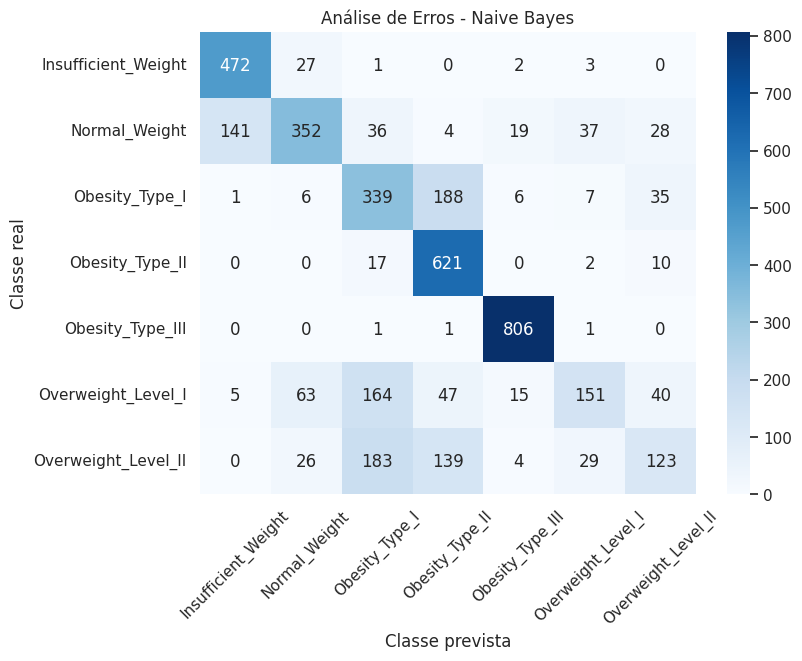

In [734]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


acc_nb = avaliar_modelo_ml(
    nb_model,
    X_val,
    y_val,
    "Naive Bayes",
    le.classes_
)

O Naive Bayes foi excelente nos extremos, como na Obesity Type III, mas sofreu muito para distinguir as classes de sobrepeso e obesidade inicial. O baixo recall em Overweight Level II e a confusão com Obesity Type I mostram que o modelo se perde onde as métricas físicas e hábitos se sobrepõem.

Classificação 3 modelos

### **Árvore de Decisão (Decision Tree)**

**Funcionamento**
A Árvore de Decisão é um modelo supervisionado que particiona o espaço de atributos em regiões homogêneas por meio de regras sequenciais do tipo “se-então”. Em cada divisão, o algoritmo seleciona a variável e o ponto de corte que melhor reduz a impureza dos dados, utilizando o critério de Gini.

**Configurações adotadas**
*   **criterion = "gini"**: mede a impureza dos nós e busca divisões mais puras.
*   **max_depth = 8**: limita a profundidade da árvore para evitar overfitting.
*   **min_samples_split = 5**: impede divisões em amostras muito pequenas.
*   **random_state = 42**: garante reprodutibilidade dos resultados.

**Justificativa**
A Árvore de Decisão foi escolhida por sua interpretabilidade e capacidade de capturar relações não lineares entre variáveis, permitindo identificar padrões associados ao risco de obesidade.


══════════════════════════════════════════════════
RESULTADO DO MODELO: Decision Tree
══════════════════════════════════════════════════
Acurácia obtida: 0.8644

Relatório detalhado por classe:

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.92      0.92       505
      Normal_Weight       0.82      0.87      0.84       617
     Obesity_Type_I       0.81      0.81      0.81       582
    Obesity_Type_II       0.93      0.95      0.94       650
   Obesity_Type_III       1.00      0.99      0.99       809
 Overweight_Level_I       0.73      0.70      0.72       485
Overweight_Level_II       0.74      0.71      0.72       504

           accuracy                           0.86      4152
          macro avg       0.85      0.85      0.85      4152
       weighted avg       0.86      0.86      0.86      4152



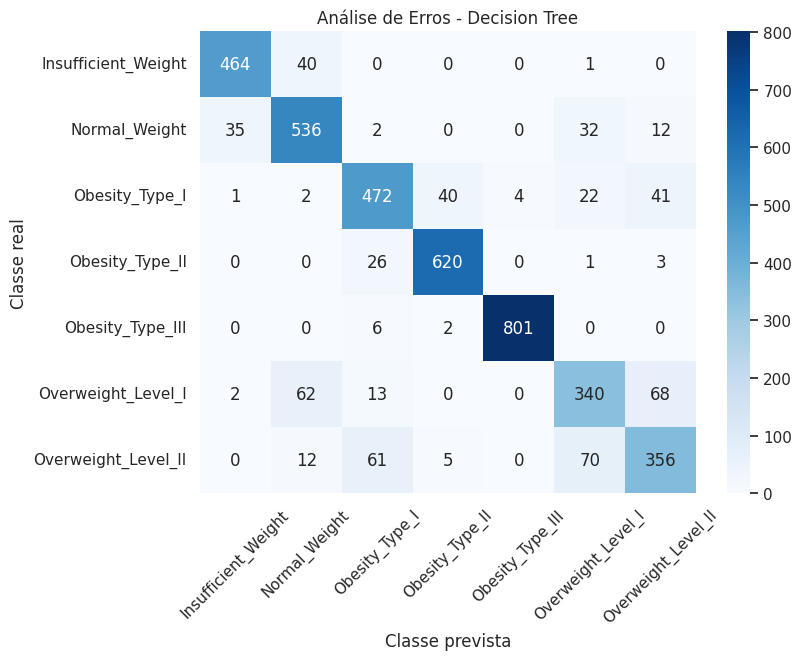

In [735]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

acc_dt = avaliar_modelo_ml(
    dt_model,
    X_val,
    y_val,
    "Decision Tree",
    le.classes_
)

### **Random Forest**

**Funcionamento**
O Random Forest é um método ensemble baseado na combinação de múltiplas árvores de decisão treinadas em subconjuntos diferentes dos dados. A predição final é obtida por votação majoritária entre todas as árvores, o que reduz a variância e melhora a generalização.

**Configurações adotadas**
*   **n_estimators = 150**: número de árvores no conjunto.
*   **max_depth = 12**: limita a complexidade de cada árvore.
*   **min_samples_split = 5**: evita overfitting em divisões muito específicas.
*   **random_state = 42**: garante reprodutibilidade.
*   **n_jobs = -1**: paraleliza o treinamento para maior eficiência.

**Justificativa**
O Random Forest foi escolhido por sua robustez e capacidade de generalização, reduzindo o overfitting presente em árvores individuais por meio da agregação de múltiplos modelos.


══════════════════════════════════════════════════
RESULTADO DO MODELO: Random Forest
══════════════════════════════════════════════════
Acurácia obtida: 0.8851

Relatório detalhado por classe:

                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.93      0.93       505
      Normal_Weight       0.84      0.90      0.87       617
     Obesity_Type_I       0.85      0.86      0.85       582
    Obesity_Type_II       0.95      0.95      0.95       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.79      0.70      0.74       485
Overweight_Level_II       0.76      0.77      0.76       504

           accuracy                           0.89      4152
          macro avg       0.87      0.87      0.87      4152
       weighted avg       0.88      0.89      0.88      4152



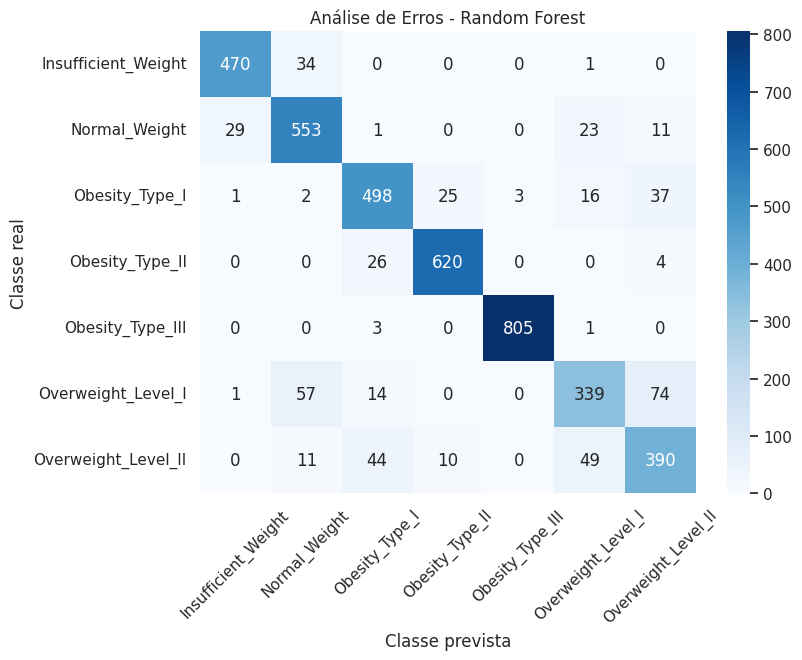

In [736]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

acc_rf = avaliar_modelo_ml(
    rf_model,
    X_val,
    y_val,
    "Random Forest",
    le.classes_
)

### **k-NN (K-Nearest Neighbors)**

**Funcionamento**
O k-NN é um algoritmo baseado em instâncias que classifica uma nova amostra com base na classe majoritária entre seus k vizinhos mais próximos no espaço de atributos.

**Configurações adotadas**
*   **n_neighbors = 7**: número de vizinhos considerados.
*   **weights = "distance"**: dá maior peso aos vizinhos mais próximos.
*   **metric = "minkowski"**: métrica de distância generalizada (equivalente à euclidiana quando p=2).

**Justificativa**
O k-NN foi escolhido por sua simplicidade e por não assumir distribuições estatísticas dos dados, sendo útil como modelo baseado em similaridade entre observações.


══════════════════════════════════════════════════
RESULTADO DO MODELO: k-NN
══════════════════════════════════════════════════
Acurácia obtida: 0.8695

Relatório detalhado por classe:

                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.95      0.92       505
      Normal_Weight       0.86      0.84      0.85       617
     Obesity_Type_I       0.83      0.84      0.83       582
    Obesity_Type_II       0.94      0.94      0.94       650
   Obesity_Type_III       0.97      0.99      0.98       809
 Overweight_Level_I       0.77      0.69      0.73       485
Overweight_Level_II       0.74      0.76      0.75       504

           accuracy                           0.87      4152
          macro avg       0.86      0.86      0.86      4152
       weighted avg       0.87      0.87      0.87      4152



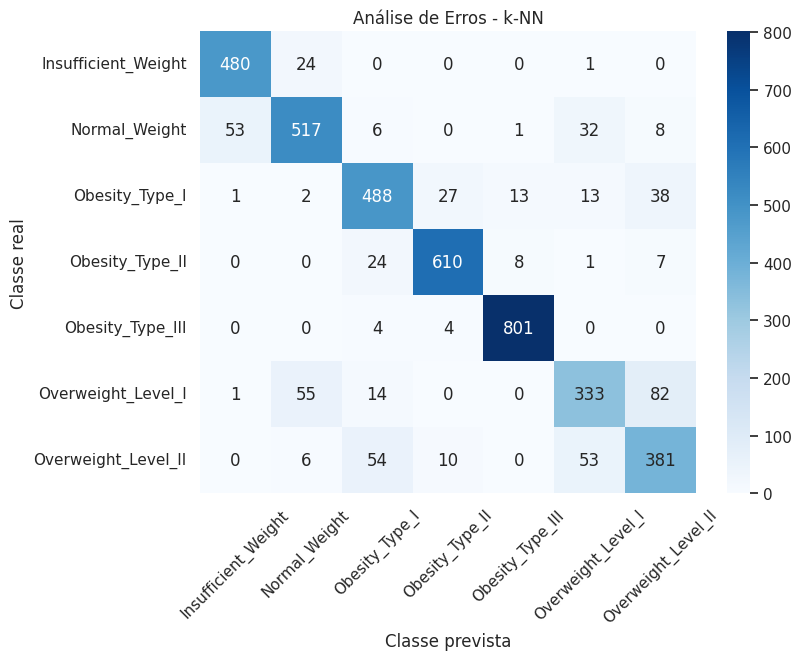

In [737]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance",
    metric="minkowski"
)

knn_model.fit(X_train, y_train)

acc_knn = avaliar_modelo_ml(
    knn_model,
    X_val,
    y_val,
    "k-NN",
    le.classes_
)

In [739]:
resultados = pd.DataFrame({
    "Modelo": [
        "Naive Bayes",
        "Árvore de Decisão",
        "Random Forest",
        "k-NN"
    ],
    "Acurácia (Validação)": [
        acc_nb,
        acc_dt,
        acc_rf,
        acc_knn
    ]
})

resultados = resultados.sort_values(by="Acurácia (Validação)", ascending=False)

print(resultados)

              Modelo  Acurácia (Validação)
2      Random Forest              0.885116
3               k-NN              0.869461
1  Árvore de Decisão              0.864403
0        Naive Bayes              0.689788


O melhor modelo foi o Random Forest, que obteve a maior acurácia na validação local (0.8851), superando k-NN (0.8695), Árvore de Decisão (0.8644) e Naive Bayes (0.6898).

O Random Forest foi escolhido para a submissão final por apresentar melhor desempenho preditivo e maior capacidade de generalização, combinando múltiplas árvores de decisão e reduzindo overfitting, o que o torna mais robusto para dados não vistos no conjunto de teste do Kaggle.